# Import

In [37]:
import shap
import pandas as pd
import joblib
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Chargement des données

In [38]:
df = pd.read_csv("../data/processed/feature_engineered_telco_churn.csv")

X = df.drop(columns=["Churn"])
y = df["Churn"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

log_model = joblib.load("../models/churn_model_log.pkl")

# Préparation des données pour SHAP

In [39]:
X_train_transformed = log_model.named_steps["preprocessor"].transform(X_train)

X_test_transformed = log_model.named_steps["preprocessor"].transform(X_test)

In [40]:
feature_names = log_model.named_steps["preprocessor"].get_feature_names_out()

In [41]:
if not isinstance(X_train_transformed, np.ndarray):
    X_train_transformed = X_train_transformed.toarray()

if not isinstance(X_test_transformed, np.ndarray):
    X_test_transformed = X_test_transformed.toarray()

X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Explainer SHAP

In [42]:
explainer = shap.LinearExplainer(
    log_model.named_steps["classifier"],
    X_train_transformed
)

In [43]:
shap_values = explainer.shap_values(X_test_transformed)

# Graphique SHAP global

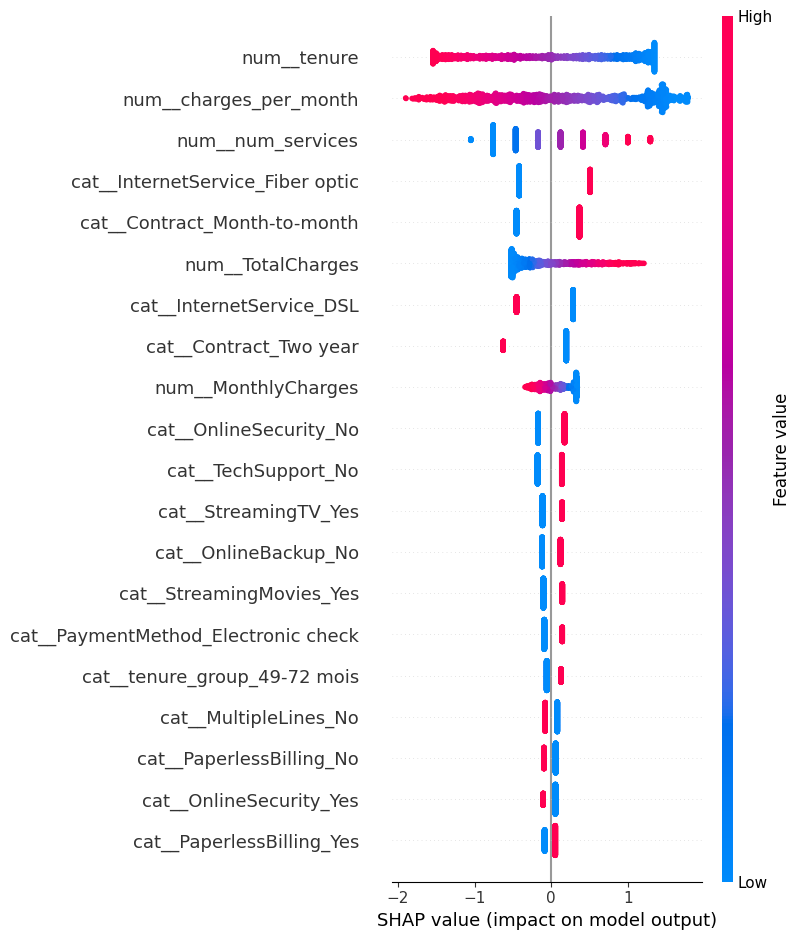

In [44]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

# Graphique SHAP bar

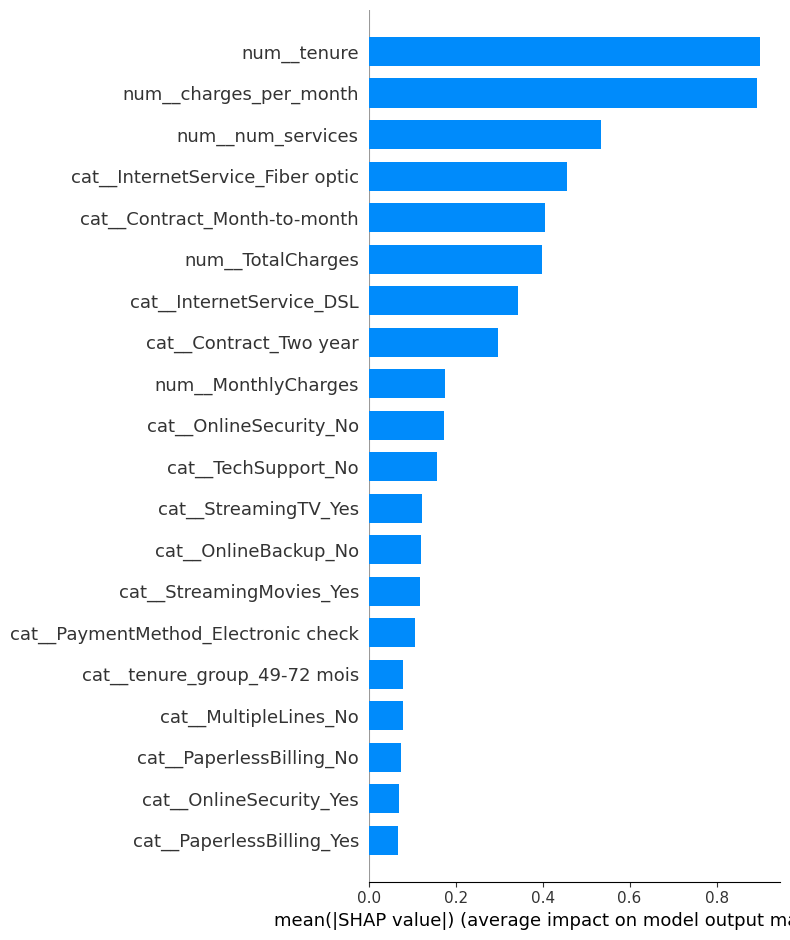

In [45]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

# Explication client individuel

In [46]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_transformed[0],
    feature_names=feature_names
)

# Impact exact du prix

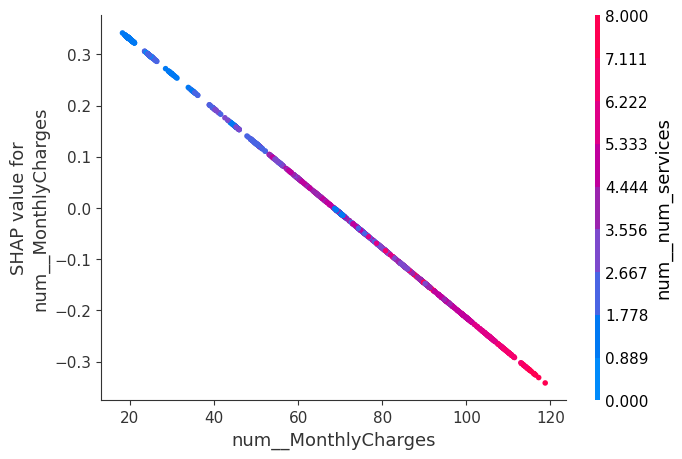

In [48]:
shap.dependence_plot("num__MonthlyCharges", shap_values, X_test_transformed_df)

# Ancienneté

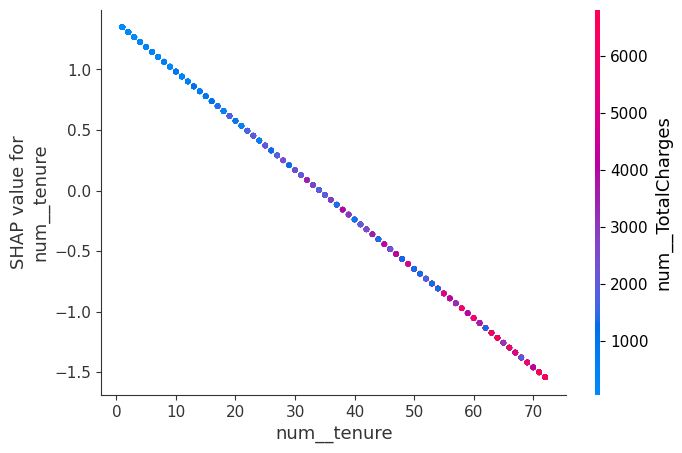

In [49]:
shap.dependence_plot("num__tenure", shap_values, X_test_transformed_df)

# Interprétation

Les variables ayant le plus d'impact sont :
- num__tenure
- num__charges_per_month
- num__num_services
- cat__InternetService_Fiber optic
- cat__Contract_Month-to-Month

Les clients avec un abonnement au mois et peu de services ont un risque de churn plus élevé, le prix des contrats joue également un rôle clé dans les risques de churn si les prix sont plus élevés que d'habitude.